# Model Training

In [2]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split


Load data

In [ ]:
df_matches_with_features = pd.read_csv("model/matches_with_features.csv")

Split features and labels

In [4]:
feature_cols = [
    "total_goals_team1",
    "num_players_with_goals_team1",
    "max_goals_by_single_player_team1",
    "total_matches_team1",
    "matches_with_goals_team1",
    "matches_without_goals_team1",
    "avg_goals_per_match_team1",
    "total_goals_team2",
    "num_players_with_goals_team2",
    "max_goals_by_single_player_team2",
    "total_matches_team2",
    "matches_with_goals_team2",
    "matches_without_goals_team2",
    "avg_goals_per_match_team2",
    "goals_diff",
    "matches_diff",
    "avg_goals_diff",
    "num_players_with_goals_diff",
    "max_goals_diff"
]

X = df_matches_with_features[feature_cols]
y = df_matches_with_features["win"]

Split to training and testing dataset

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Training with simple Random Forest model

In [6]:
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

['output/feature_columns.pkl']

Evaluation

In [12]:
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

feat_imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": clf.feature_importances_
}).sort_values(by="importance", ascending=False)

print(feat_imp.head(10))

Accuracy: 0.6558441558441559
              precision    recall  f1-score   support

           0       0.64      0.70      0.67        77
           1       0.67      0.61      0.64        77

    accuracy                           0.66       154
   macro avg       0.66      0.66      0.66       154
weighted avg       0.66      0.66      0.66       154

                         feature  importance
16                avg_goals_diff    0.113740
14                    goals_diff    0.089458
17   num_players_with_goals_diff    0.072017
15                  matches_diff    0.065736
6      avg_goals_per_match_team1    0.063699
18                max_goals_diff    0.062897
13     avg_goals_per_match_team2    0.055786
7              total_goals_team2    0.048370
0              total_goals_team1    0.047028
1   num_players_with_goals_team1    0.044389


Output model, feature columns and metadata

In [ ]:
joblib.dump(clf, "model/worldcup_model.pkl")
joblib.dump(feature_cols, "model/feature_columns.pkl")
model_info = {
    "model": "RandomForestClassifier",
    "trained_on": "Worldcup data 2002 - 2022",
    "accuracy": accuracy,
    "features": feature_cols
}

joblib.dump(model_info, "model/model_metadata.pkl")

['output/model_metadata.pkl']

Visualization

/var/folders/xw/cqtpjnb545180n_0bdh4k0500000gn/T/ipykernel_26506/390937265.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


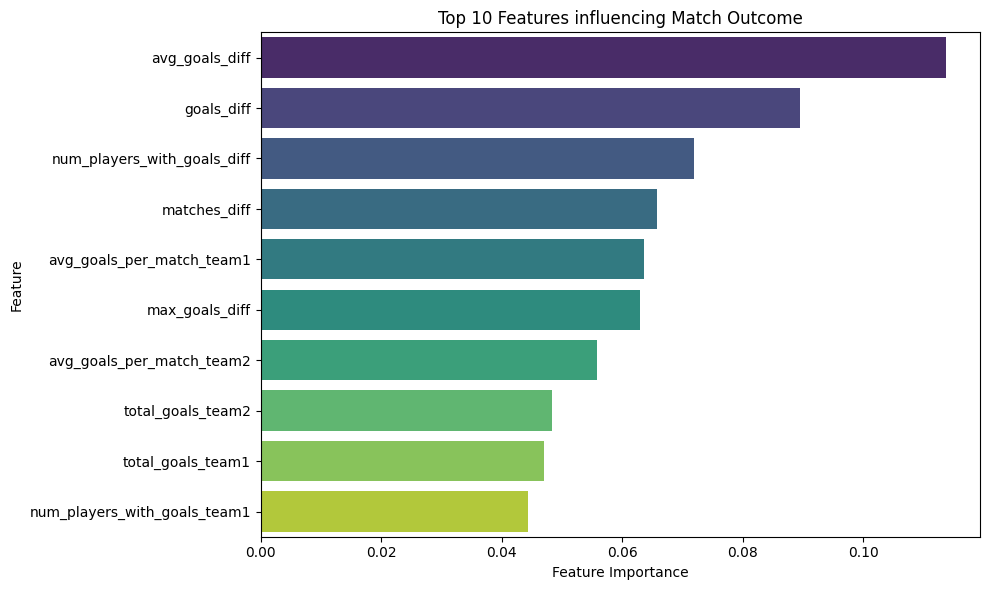

In [8]:
top_features = feat_imp.sort_values(by="importance", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x="importance",
    y="feature",
    data=top_features,
    palette="viridis"
)
plt.title("Top 10 Features influencing Match Outcome")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

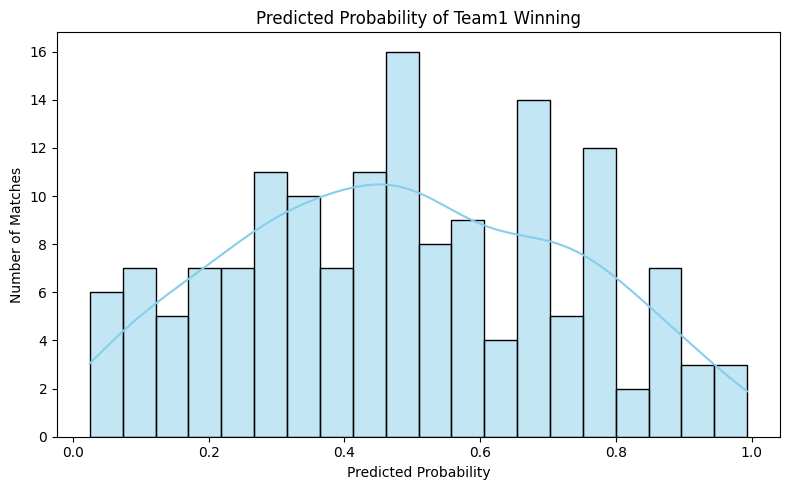

In [9]:
y_prob = clf.predict_proba(X_test)[:,1]

plt.figure(figsize=(8,5))
sns.histplot(y_prob, bins=20, kde=True, color="skyblue")
plt.title("Predicted Probability of Team1 Winning")
plt.xlabel("Predicted Probability")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()